In [1]:
import pandas as pd
import utils as uti


In [2]:
df = pd.read_pickle("../data/01_df_train.pkl")

In [3]:
import pickle
from pathlib import Path

models_file_path = Path("../data/02_dic_models.pkl")

if models_file_path.exists():
    print('loading model file')
    with models_file_path.open("rb") as file:
        models = pickle.load(file)
else:
    print('creating new model file')
    models = {}

loading model file


# param optimization

In [4]:
walds = pd.read_pickle("../data/01_df_walds.pkl")
walds.head()

,var,auc,corr,corr ind
0,checking_account_status_woe,0.700714,0.228923,False
1,credit_history_woe,0.641429,0.414942,True
2,purpose_woe,0.609829,0.137224,False
3,savings_account_bonds_woe,0.607543,0.228923,False
4,duration_months_woe,0.602352,0.181447,False


## load info from previous steps

In [5]:
event = 'bad'

In [6]:
woe_vars = walds['var'].tolist() 
raw_vars = [woe_vars.removesuffix("_woe") for woe_vars in woe_vars]
raw_vars

['checking_account_status',
 'credit_history',
 'purpose',
 'savings_account_bonds',
 'duration_months',
 'employment_since',
 'property',
 'housing',
 'other_installment_plans',
 'credit_amount',
 'installment_rate_percent',
 'telephone',
 'existing_credits_at_bank',
 'residence_since']

In [7]:
X = df[raw_vars]
y = df[event]

In [8]:
import numpy as np
import optuna
import toad

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier


def objective(trial):
    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "tree_method": "hist",
        "n_estimators": 3000,
    
        "max_depth": trial.suggest_int("max_depth", 2, 5),
    
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.25, log=True
        ),
    
        "min_child_weight": trial.suggest_float(
            "min_child_weight", 1.0, 30.0, log=True
        ),
    
        "subsample": trial.suggest_float(
            "subsample", 0.7, 1.0
        ),
    
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.7, 1.0
        ),
    
        "gamma": trial.suggest_float(
            "gamma", 1e-6, 5.0, log=True
        ),
    
        "reg_alpha": trial.suggest_float(
            "reg_alpha", 1e-4, 10.0, log=True
        ),
    
        "reg_lambda": trial.suggest_float(
            "reg_lambda", 1.0, 100.0, log=True
        ),
    
        "random_state": 42,
        "n_jobs": -1,
        "early_stopping_rounds": 100,
    }


    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    fold_scores = []

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y)):
        X_fold_train = X.iloc[train_idx].copy()
        X_fold_valid = X.iloc[valid_idx].copy()

        y_fold_train = y.iloc[train_idx]
        y_fold_valid = y.iloc[valid_idx]

        # Fit bins only on this fold's training data
        combiner = toad.transform.Combiner()

        combiner.fit(
            X_fold_train,
            y=y_fold_train,
            method="chi",
            min_samples=0.05
        )

        # Transform both sets using training-fold bin rules
        X_fold_train_bins = combiner.transform(X_fold_train)
        X_fold_valid_bins = combiner.transform(X_fold_valid)

        # Fit WoE only on this fold's training bins
        woe = toad.transform.WOETransformer()

        woe.fit(
            X_fold_train_bins,
            y_fold_train
        )

        # Transform validation data using training-fold WoE mappings
        X_fold_train_woe = woe.transform(X_fold_train_bins)
        X_fold_valid_woe = woe.transform(X_fold_valid_bins)


        # add suffix


        X_fold_train_woe = X_fold_train_woe.add_suffix("_woe")
        X_fold_valid_woe = X_fold_valid_woe.add_suffix("_woe")

        model = XGBClassifier(**params)

        model.fit(
            X_fold_train_woe,
            y_fold_train,
            eval_set=[(X_fold_valid_woe, y_fold_valid)],
            verbose=False
        )

        valid_probabilities = model.predict_proba(
            X_fold_valid_woe
        )[:, 1]

        fold_auc = roc_auc_score(
            y_fold_valid,
            valid_probabilities
        )

        fold_scores.append(fold_auc)

        # Optional pruning during the Optuna trial
        trial.report(np.mean(fold_scores), step=fold)

        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_scores)


In [9]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=10,
        n_warmup_steps=2
    )
)

study.optimize(
    objective,
    n_trials=250,
    show_progress_bar=True
)

[I 2026-09-12 05:06:38,755] A new study created in memory with name: no-name-6cafda3a-a380-45f6-b0ca-14f83101a79a


  0%|          | 0/250 [00:00<?, ?it/s]

[I 2026-09-12 05:06:39,186] Trial 0 finished with value: 0.7758095238095238 and parameters: {'max_depth': 3, 'learning_rate': 0.2133249073808361, 'min_child_weight': 12.057126287443763, 'subsample': 0.8795975452591109, 'colsample_bytree': 0.7468055921327309, 'gamma': 1.1091814877139725e-05, 'reg_alpha': 0.00019517224641449495, 'reg_lambda': 53.99484409787433}. Best is trial 0 with value: 0.7758095238095238.
[I 2026-09-12 05:06:39,452] Trial 1 finished with value: 0.767047619047619 and parameters: {'max_depth': 4, 'learning_rate': 0.09768839753070749, 'min_child_weight': 1.0725209743171995, 'subsample': 0.9909729556485982, 'colsample_bytree': 0.9497327922401265, 'gamma': 2.6451684446721577e-05, 'reg_alpha': 0.0008111941985431928, 'reg_lambda': 2.32706770838378}. Best is trial 0 with value: 0.7758095238095238.
[I 2026-09-12 05:06:39,768] Trial 2 finished with value: 0.7853809523809524 and parameters: {'max_depth': 3, 'learning_rate': 0.05414745020542119, 'min_child_weight': 4.34545410972

In [10]:
print("Best AUC:", study.best_value)
print("Best parameters:")
print(study.best_params)

Best AUC: 0.7970476190476191
Best parameters:
{'max_depth': 3, 'learning_rate': 0.16711305519830927, 'min_child_weight': 2.016928543585918, 'subsample': 0.7441157313016116, 'colsample_bytree': 0.8713963141192341, 'gamma': 0.0005480721796823238, 'reg_alpha': 0.0001900955838646342, 'reg_lambda': 34.509617036328684}


## optimization summary

In [11]:
import matplotlib.pyplot as plt

In [12]:
from optuna.importance import get_param_importances

importance_dict = get_param_importances(study)

/tmp/ipykernel_2556216/3694072603.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_optimization_history(study)


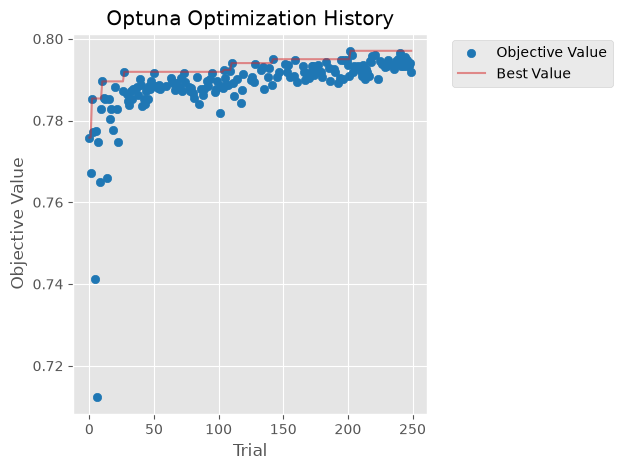

In [13]:
fig = optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title("Optuna Optimization History")
plt.tight_layout()
plt.show()

/tmp/ipykernel_2556216/2144959284.py:1: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_param_importances(study)


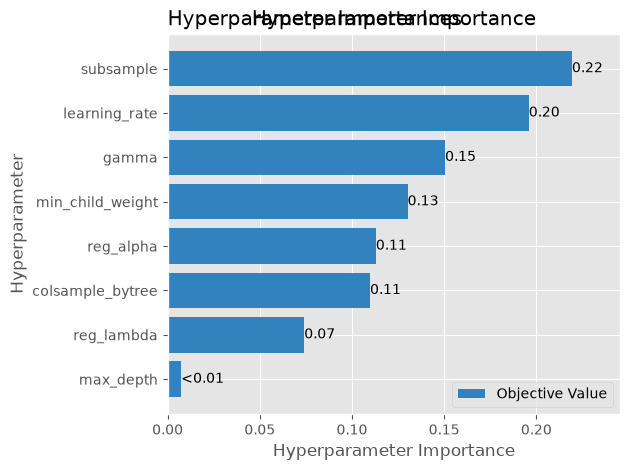

In [14]:
fig = optuna.visualization.matplotlib.plot_param_importances(study)
plt.title("Hyperparameter Importance")
plt.tight_layout()
plt.show()

/tmp/ipykernel_2556216/1725605251.py:1: ExperimentalWarning: optuna.visualization.matplotlib._slice.plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_slice(
/tmp/ipykernel_2556216/1725605251.py:5: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


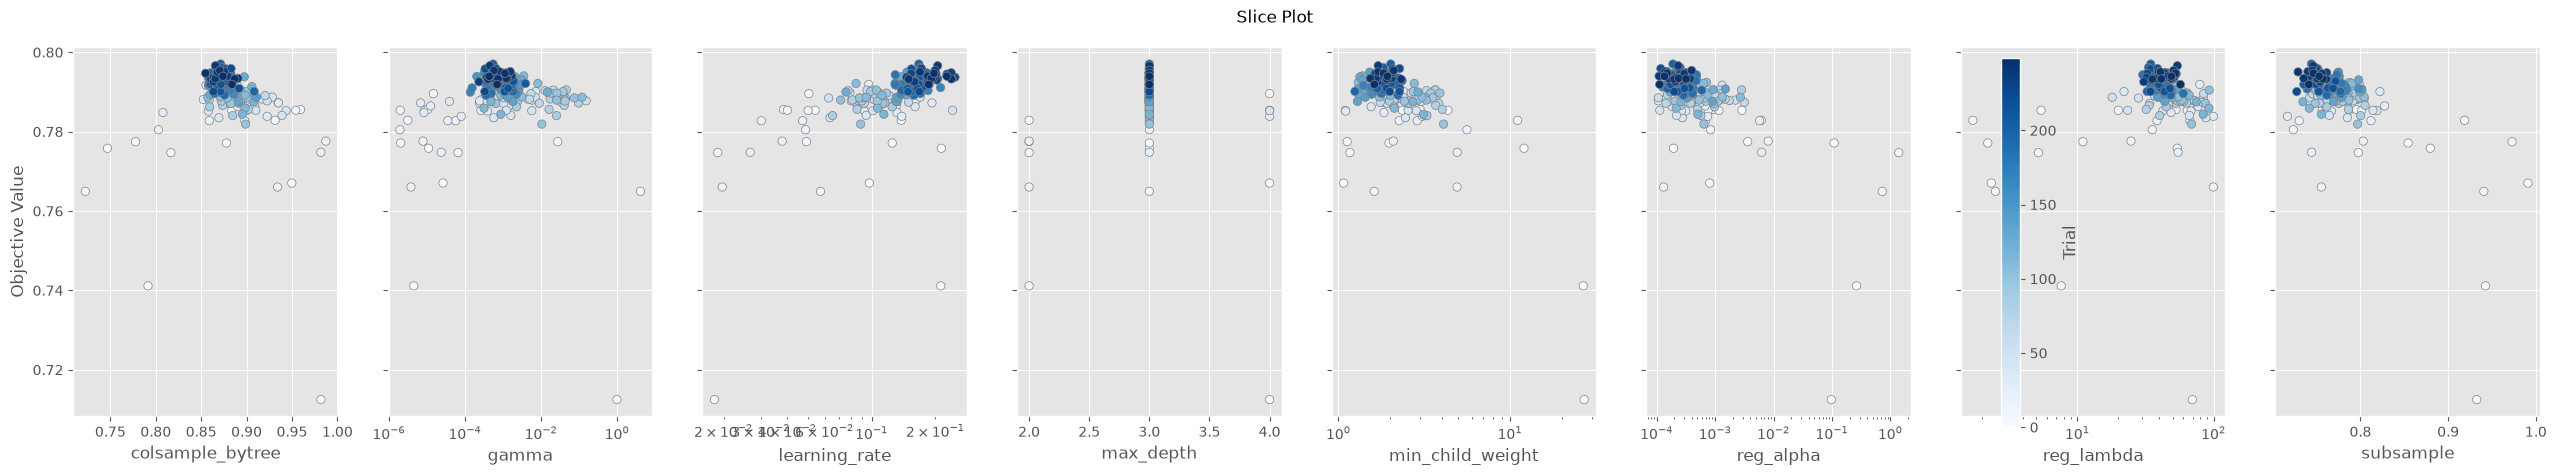

In [15]:
fig = optuna.visualization.matplotlib.plot_slice(
    study,
    params=list(importance_dict.keys())
)
plt.tight_layout()
plt.show()

In [18]:
trials_df = study.trials_dataframe()

best_trials = (
    trials_df
    .query("state == 'COMPLETE'")
    .sort_values("value", ascending=False)
    .head(10)
)

In [19]:
best_trials

,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_gamma,params_learning_rate,params_max_depth,params_min_child_weight,params_reg_alpha,params_reg_lambda,params_subsample,system_attrs_tpe:relative_params:0,state
202,202,0.797048,2026-09-12 05:07:51.345906,2026-09-12 05:07:51.789138,0 days 00:00:00.443232,0.871396,0.000548,0.167113,3,2.016929,0.000190,34.509617,0.744116,"{""colsample_bytree"": 0.8713963141192341, ""gamm...",COMPLETE
240,240,0.796619,2026-09-12 05:08:05.697331,2026-09-12 05:08:06.037923,0 days 00:00:00.340592,0.865652,0.000449,0.205085,3,1.703613,0.000233,54.119468,0.745960,"{""colsample_bytree"": 0.865652221745692, ""gamma...",COMPLETE
203,203,0.796143,2026-09-12 05:07:51.790661,2026-09-12 05:07:52.098435,0 days 00:00:00.307774,0.873075,0.000447,0.169849,3,1.827414,0.000253,33.223730,0.748678,"{""colsample_bytree"": 0.8730748371176932, ""gamm...",COMPLETE
221,221,0.795905,2026-09-12 05:07:59.997356,2026-09-12 05:08:00.336872,0 days 00:00:00.339516,0.882847,0.000654,0.171782,3,2.271511,0.000118,38.692293,0.750100,"{""colsample_bytree"": 0.8828465807404781, ""gamm...",COMPLETE
219,219,0.795810,2026-09-12 05:07:59.439425,2026-09-12 05:07:59.810090,0 days 00:00:00.370665,0.877064,0.000337,0.154234,3,2.071483,0.000241,34.282146,0.751521,"{""colsample_bytree"": 0.8770635986616329, ""gamm...",COMPLETE
244,244,0.795429,2026-09-12 05:08:07.102289,2026-09-12 05:08:07.478085,0 days 00:00:00.375796,0.870450,0.000577,0.199356,3,2.101819,0.000397,50.858702,0.745415,"{""colsample_bytree"": 0.8704504399790586, ""gamm...",COMPLETE
239,239,0.795143,2026-09-12 05:08:05.342866,2026-09-12 05:08:05.696151,0 days 00:00:00.353285,0.875350,0.001546,0.198680,3,1.733293,0.000150,39.302506,0.740036,"{""colsample_bytree"": 0.8753499930148654, ""gamm...",COMPLETE
242,242,0.795048,2026-09-12 05:08:06.357234,2026-09-12 05:08:06.758372,0 days 00:00:00.401138,0.867742,0.000799,0.169165,3,1.702479,0.000139,40.597697,0.728854,"{""colsample_bytree"": 0.8677415018590301, ""gamm...",COMPLETE
142,142,0.795000,2026-09-12 05:07:32.724214,2026-09-12 05:07:33.081466,0 days 00:00:00.357252,0.863666,0.000866,0.146816,3,1.522646,0.000229,37.586916,0.774985,"{""colsample_bytree"": 0.8636657053339908, ""gamm...",COMPLETE
231,231,0.794857,2026-09-12 05:08:02.826257,2026-09-12 05:08:03.178085,0 days 00:00:00.351828,0.872066,0.000605,0.237652,3,2.067695,0.000318,43.483212,0.761541,"{""colsample_bytree"": 0.8720658535908844, ""gamm...",COMPLETE


# fit best model

In [20]:
# use woe from entire training data
X = df[woe_vars]

In [21]:
# from xgboost import XGBClassifier

best_params = {
    **study.best_params,
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": -1,
}

final_model = XGBClassifier(**best_params)

final_model.fit(X, y, verbose=False)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8713963141192341
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


# partial dependence plots

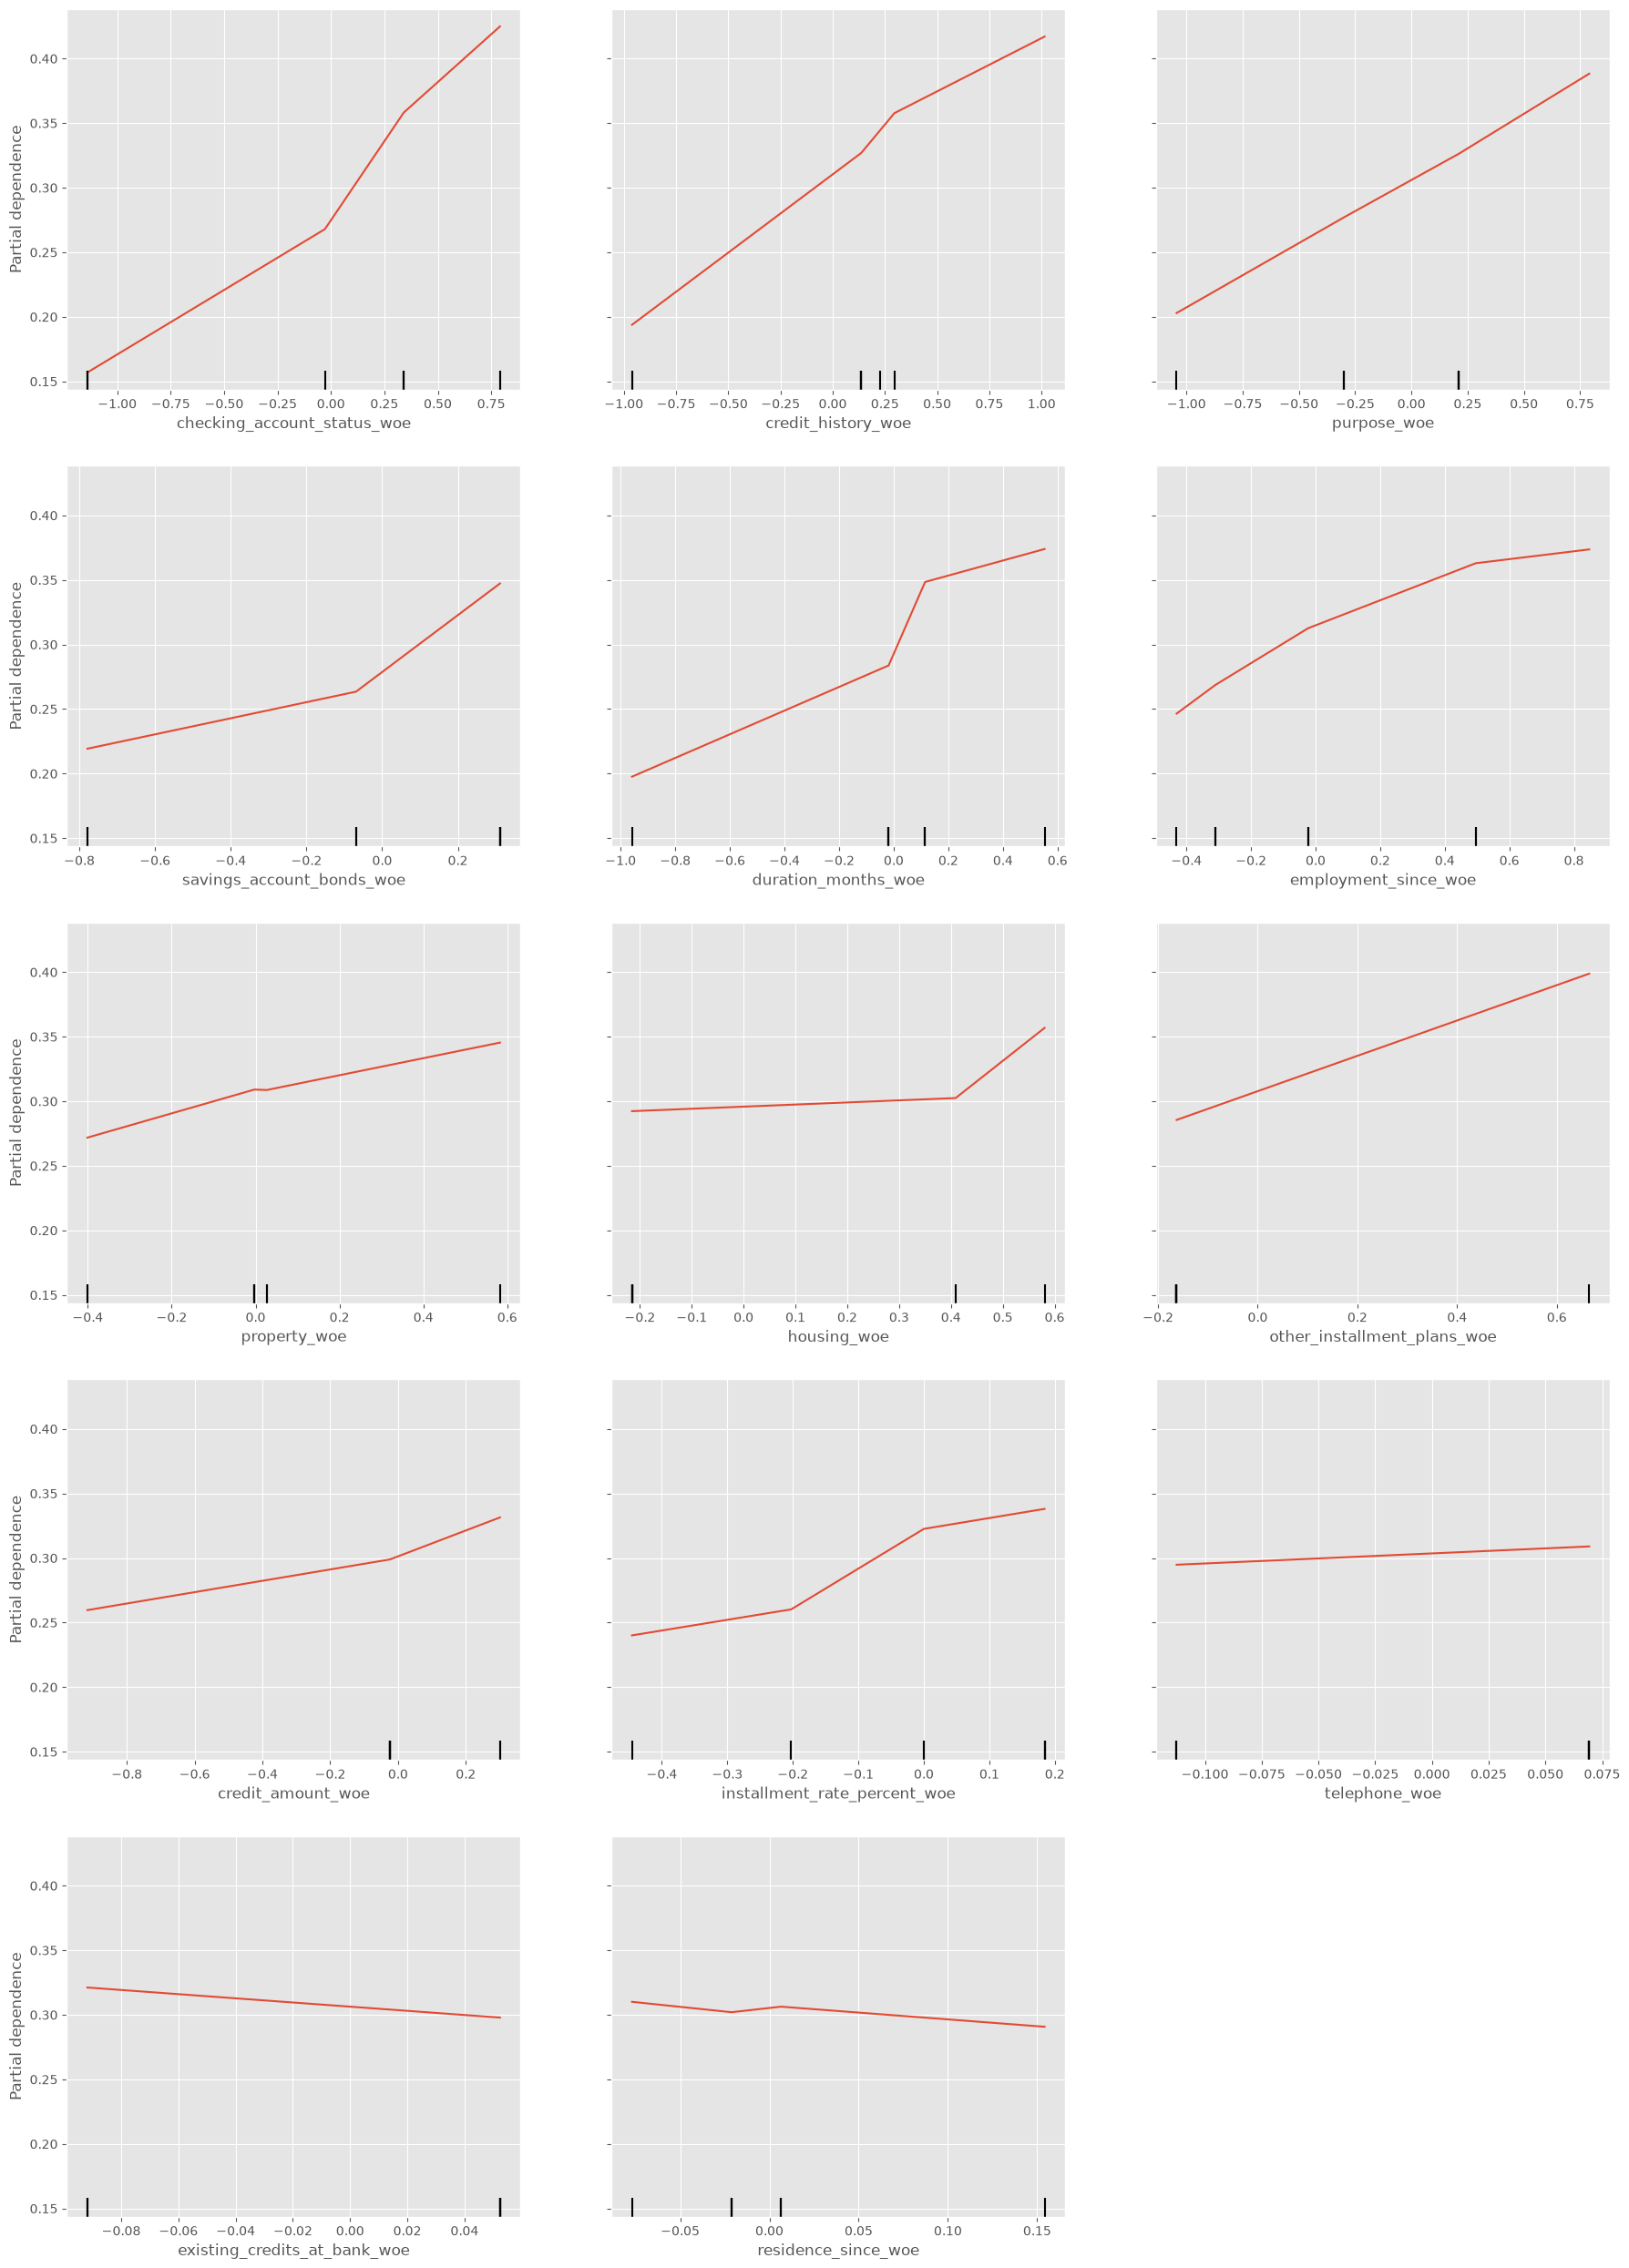

In [22]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

features = walds["var"].tolist()

display = PartialDependenceDisplay.from_estimator(
    final_model,
    X,
    features=features,
    n_cols=3
)

n_rows = (len(features) + 2) // 3

display.figure_.set_size_inches(
    18,
    5 * n_rows
)

display.figure_.tight_layout()

plt.show()

# save models

In [23]:
models['xgb woe'] = final_model

In [24]:
with open(models_file_path, "wb") as file:
    pickle.dump(models, file)